In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

Ques1: Build a simple autoencoder in Python using Keras to compress and reconstruct 28x28 grayscale images from the Fashion MNIST dataset. Train for 5 epochs and display one original and its reconstructed image side by side.


In [2]:
# Load Fashion MNIST dataset
(x_train, _), (x_test, _) = fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Normalize pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [4]:
# Flatten 28x28 images into 784-dimensional vectors
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

In [5]:
# Autoencoder architecture
input_dim = 784
encoding_dim = 64

In [6]:
# Encoder
input_img = Input(shape=(input_dim,))
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(encoding_dim, activation='relu')(encoded)

In [7]:
# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(input_dim, activation='sigmoid')(decoded)

In [8]:
# Autoencoder model
autoencoder = Model(input_img, decoded)

# Compile model
autoencoder.compile(optimizer=Adam(), loss='binary_crossentropy')

In [9]:

# Train for 5 epochs
autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.3650 - val_loss: 0.3123
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.3021 - val_loss: 0.2988
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.2939 - val_loss: 0.2948
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.2888 - val_loss: 0.2890
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.2853 - val_loss: 0.2865


In [10]:
# Reconstruct test images
decoded_imgs = autoencoder.predict(x_test)

# Display one original and reconstructed image
n = 1
plt.figure(figsize=(6, 3))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


<Figure size 600x300 with 0 Axes>

<Figure size 600x300 with 0 Axes>

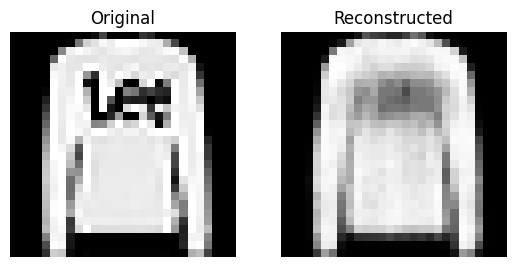

In [11]:
# Original image
plt.subplot(1, 2, 1)
plt.imshow(x_test[n].reshape(28, 28), cmap='gray')
plt.title("Original")
plt.axis('off')

# Reconstructed image
plt.subplot(1, 2, 2)
plt.imshow(decoded_imgs[n].reshape(28, 28), cmap='gray')
plt.title("Reconstructed")
plt.axis('off')

plt.show()

Ques 2 :Modify your autoencoder's loss function to use Binary Crossentropy (BCE) instead of Mean Squared Error (MSE), then compare the reconstruction quality visually for 3 test images.<br><br><em><strong>Hint:</strong> Use model.compile(loss='binary_crossentropy', optimizer='adam').</em>


In [12]:
# Build Autoencoder
input_img = Input(shape=(784,))

# Encoder
encoded = Dense(128, activation='relu')(input_img)
encoded = Dense(64, activation='relu')(encoded)

# Decoder
decoded = Dense(128, activation='relu')(encoded)
decoded = Dense(784, activation='sigmoid')(decoded)

In [13]:
# Model
autoencoder = Model(input_img, decoded)

# Compile with Binary Crossentropy
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [14]:
# Train
autoencoder.fit(
    x_train,
    x_train,
    epochs=5,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.3682 - val_loss: 0.3126
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.3033 - val_loss: 0.3002
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.2948 - val_loss: 0.2939
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - loss: 0.2893 - val_loss: 0.2894
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.2860 - val_loss: 0.2870


In [15]:
# Reconstruct images
decoded_imgs = autoencoder.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


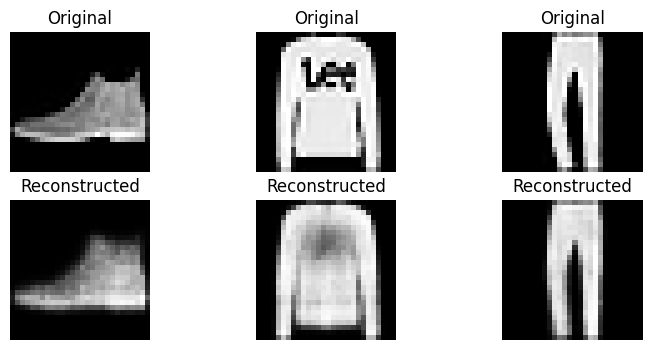

In [16]:
# Display 3 original and reconstructed images
n = 3
plt.figure(figsize=(9,4))

for i in range(n):

    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstruction
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')

plt.show()

Ques 3: Use your trained autoencoder to denoise images: add random noise to 10 Fashion MNIST test images, pass them through the autoencoder, and display the noisy and denoised outputs together.


In [17]:
# Generate random noise
noise_factor = 0.5

In [18]:
# Add noise to test images
x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

In [19]:
# Clip pixel values to [0, 1]
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

# Pass noisy images through the trained autoencoder
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


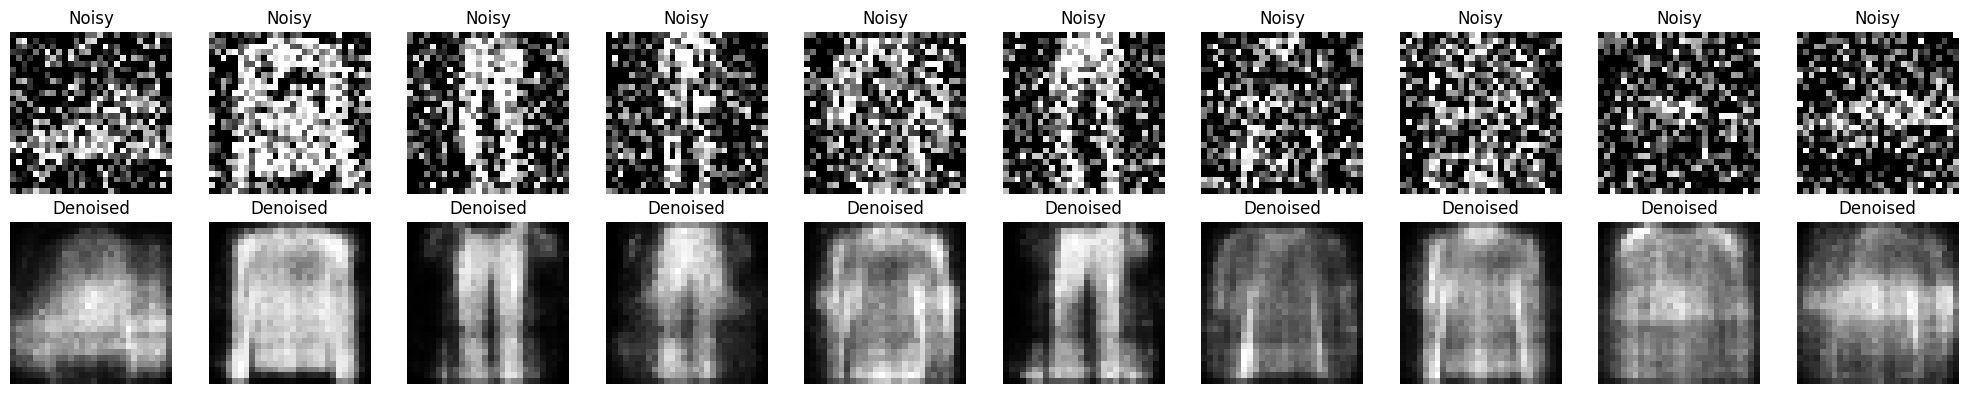

In [20]:
# Display 10 noisy and denoised images
n = 10
plt.figure(figsize=(20, 4))

for i in range(n):

    # Noisy image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

Ques 4: Build a Variational Autoencoder (VAE) using Keras for the Fashion MNIST dataset. After training, sample 5 random points from the latent space and generate new images from these points.<br><br><em><strong>Hint:</strong> Use the VAE's decoder to generate images from sampled latent vectors.</em>


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


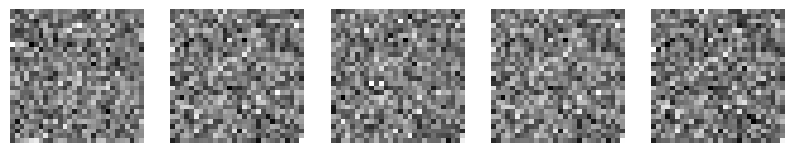

In [24]:
import tensorflow as tf
from tensorflow.keras import layers, Model

latent_dim = 2

# Encoder
encoder_inputs = layers.Input(shape=(784,))
x = layers.Dense(256, activation="relu")(encoder_inputs)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

def sampling(args):
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=(tf.shape(z_mean)[0], latent_dim))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

z = layers.Lambda(sampling)([z_mean, z_log_var])

encoder = Model(
    encoder_inputs,
    [z_mean, z_log_var, z]
)

# Decoder
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense(256, activation="relu")(latent_inputs)
decoder_outputs = layers.Dense(
    784,
    activation="sigmoid"
)(x)

decoder = Model(latent_inputs, decoder_outputs)

# Generate 5 random images
random_latent_vectors = np.random.normal(
    size=(5, latent_dim)
)

generated_images = decoder.predict(
    random_latent_vectors
)

plt.figure(figsize=(10,2))

for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(
        generated_images[i].reshape(28,28),
        cmap='gray'
    )
    plt.axis('off')

plt.show()


Ques 5 :Use ChatGPT to explain in your own words what KL-divergence loss does in a VAE and why it is needed. Paste your prompt and ChatGPT's response as your answer.


explain KL divergence loss does in a Variational Autoencoder (VAE) and why it is necessary. in simple word

KL-Divergence Loss in a VAE (Simple Explanation)

KL-Divergence loss is a part of the loss function in a Variational Autoencoder (VAE) that helps the model learn an organized and smooth latent space.

In a VAE, an input image is not stored as a single fixed value. Instead, it is converted into a range of possible values (a probability distribution). KL-divergence measures how different this distribution is from a standard normal distribution (with mean 0 and variance 1).

It is necessary because it prevents the model from learning random and scattered representations of the data. By keeping the latent space organized, KL-divergence allows the VAE to generate new and realistic images by sampling random points from the latent space.

In simple words:
Reconstruction loss helps the VAE recreate the original image accurately.
KL-divergence loss keeps the hidden representation neat and well-organized.

Without KL-divergence, the VAE could memorize the training data and would not be able to generate meaningful new images. With KL-divergence, the model can create new data that looks similar to the training data while maintaining a smooth and structured latent space.